In [1]:
# imports
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


## Import Data

In [2]:
#import  data

IMG_SIZE = 224
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    shuffle = True,
    image_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE
)

test_data = tf.keras.utils.image_dataset_from_directory(
    directory = "data/test",
    shuffle = False,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE
)

val_data = tf.keras.utils.image_dataset_from_directory(
    directory = "data/valid",
    shuffle = True,
    image_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE
)

Found 2338 files belonging to 10 classes.
Found 50 files belonging to 10 classes.
Found 50 files belonging to 10 classes.


In [3]:
class_names = train_data.class_names
print(class_names)
class_image_dict = {class_name: None for class_name in class_names}

['AFRICAN LEOPARD', 'CARACAL', 'CHEETAH', 'CLOUDED LEOPARD', 'JAGUAR', 'LIONS', 'OCELOT', 'PUMA', 'SNOW LEOPARD', 'TIGER']


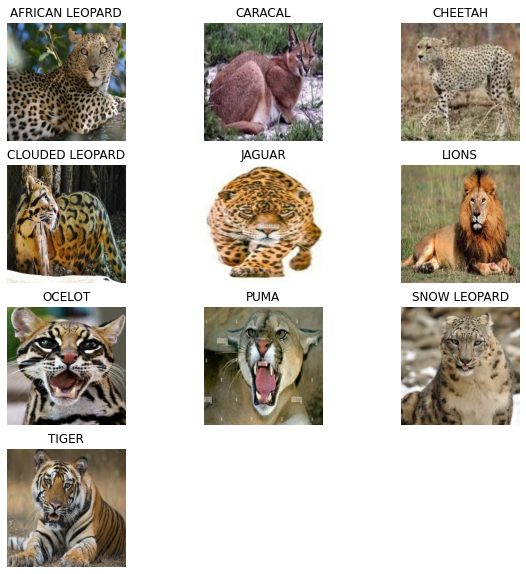

In [4]:


# Iterate over the training dataset
for image_batch, label_batch in train_data.unbatch():
    class_name = class_names[label_batch.numpy()]
    if class_image_dict[class_name] is None:
        class_image_dict[class_name] = image_batch
    elif np.all(class_image_dict[class_name] == 0):  # Check if the image is all green
        class_image_dict[class_name] = image_batch
    # Check if the dictionary is fully populated
    if all(value is not None for value in class_image_dict.values()):
        break

# Plot the images
plt.figure(figsize=(10, 10))
for i, (class_name, img) in enumerate(class_image_dict.items()):
    ax = plt.subplot(4, 3, i + 1)
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(class_name)
    plt.axis("off")
plt.show()

# plt.figure(figsize = (7,7))
# for image_batch, label_batch in train_data.take(1):
#     for i in range(9):
#         # print(image_batch[i].shape)
#         ax = plt.subplot(4,3, i+1)
#         plt.imshow(image_batch[i].numpy().astype('uint'))
#         plt.title(class_names[label_batch[i]])
#         plt.axis('off')
        

## Preprocessing

Notes for Preprocessing:

- resizing - to ensure all images are of unifrom size
- normalization - adjusts intestity values
- noise reduction - for bluring/filtering/smoothing of backgrounds - will see if we use or not
- might need to do image augmentation
- data distrabution correction

Data Distribution

2024-05-24 12:28:57.415515: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


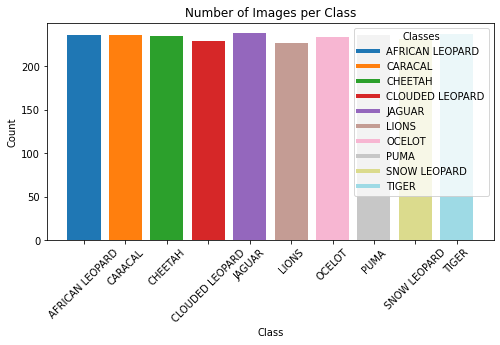

In [5]:

# Get the class labels
class_labels = train_data.class_names

# Calculate the count of images per class
class_counts = {label: 0 for label in class_labels}

for images, labels in train_data:
    for label in labels.numpy():
        class_label = class_labels[label]
        class_counts[class_label] += 1

# Define unique colors for each class
class_colors = plt.cm.tab20(np.linspace(0, 1, len(class_labels)))

# Create a bar chart with different colors for each class
plt.figure(figsize=(8, 4))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=class_colors)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Number of Images per Class')
plt.xticks(rotation=45)

# Add a legend for class colors
legend_labels = [plt.Line2D([0], [0], color=class_colors[i], lw=4, label=class_labels[i]) for i in range(len(class_labels))]
plt.legend(handles=legend_labels, title="Classes")

plt.show()


2024-05-24 12:28:57.529192: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


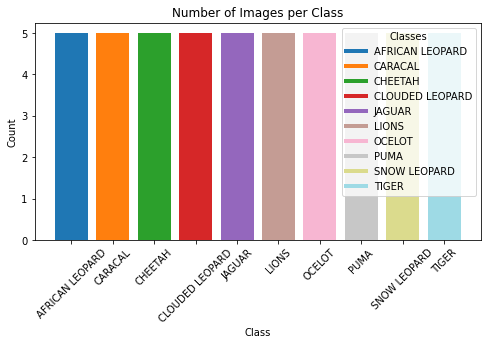

In [6]:
class_labels = val_data.class_names

# Calculate the count of images per class
class_counts = {label: 0 for label in class_labels}

for images, labels in val_data:
    for label in labels.numpy():
        class_label = class_labels[label]
        class_counts[class_label] += 1

# Define unique colors for each class
class_colors = plt.cm.tab20(np.linspace(0, 1, len(class_labels)))

# Create a bar chart with different colors for each class
plt.figure(figsize=(8, 4))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=class_colors)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Number of Images per Class')
plt.xticks(rotation=45)

# Add a legend for class colors
legend_labels = [plt.Line2D([0], [0], color=class_colors[i], lw=4, label=class_labels[i]) for i in range(len(class_labels))]
plt.legend(handles=legend_labels, title="Classes")

plt.show()

2024-05-24 12:28:57.636535: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


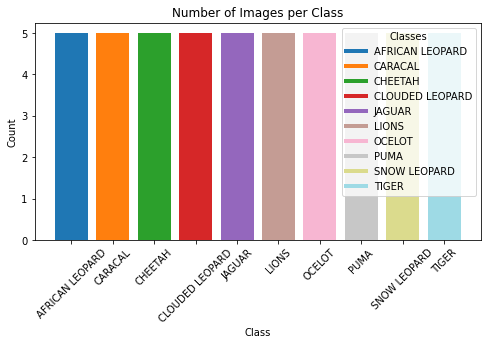

In [7]:
class_labels = test_data.class_names

# Calculate the count of images per class
class_counts = {label: 0 for label in class_labels}

for images, labels in val_data:
    for label in labels.numpy():
        class_label = class_labels[label]
        class_counts[class_label] += 1

# Define unique colors for each class
class_colors = plt.cm.tab20(np.linspace(0, 1, len(class_labels)))

# Create a bar chart with different colors for each class
plt.figure(figsize=(8, 4))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=class_colors)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Number of Images per Class')
plt.xticks(rotation=45)

# Add a legend for class colors
legend_labels = [plt.Line2D([0], [0], color=class_colors[i], lw=4, label=class_labels[i]) for i in range(len(class_labels))]
plt.legend(handles=legend_labels, title="Classes")

plt.show()

Image Augmentation

In [8]:

data_augmentation_layers = [
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
]

def  data_augmentation(images):
    for layer in  data_augmentation_layers:
        images = layer(images)
    return images



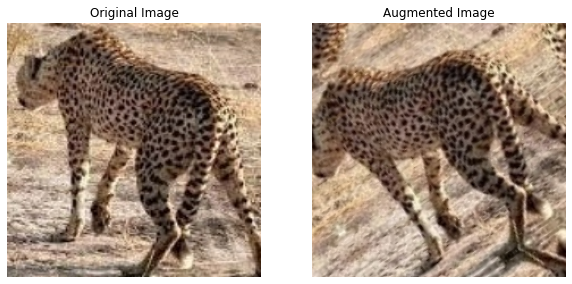

2024-05-24 12:28:58.353667: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalize pixel values to [0, 1]
    image_augment = data_augmentation(image)
    return image, label, image_augment

train_data = train_data.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

# Display an example image after data augmentation
for original_image, label, augmented_image in train_data.take(1):  # Take one batch of data
    plt.figure(figsize=(10, 5))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_image[0].numpy())  # Display the first image in the batch
    plt.title("Original Image")
    plt.axis("off")

    # Augmented image
    plt.subplot(1, 2, 2)
    plt.imshow(augmented_image[0].numpy())  # Display the first augmented image in the batch
    plt.title("Augmented Image")
    plt.axis("off")

    plt.show()

val_data = val_data.map(
    lambda img, label: (tf.cast(img, tf.float32) / 255.0, label),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

test_data = test_data.map(
    lambda img, label: (tf.cast(img, tf.float32) / 255.0, label),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [ ]:
val_data = val_data.map(
    lambda img, label: (tf.cast(img, tf.float32) / 255.0, label),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

test_data = test_data.map(
    lambda img, label: (tf.cast(img, tf.float32) / 255.0, label),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)


